### Вовед во Биоинформатика

Изработила: Зорица Ников

Индекс: 216150

### Imports

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
combined_df = pd.read_csv('./combined_dataset.csv')

### Plot Histograms

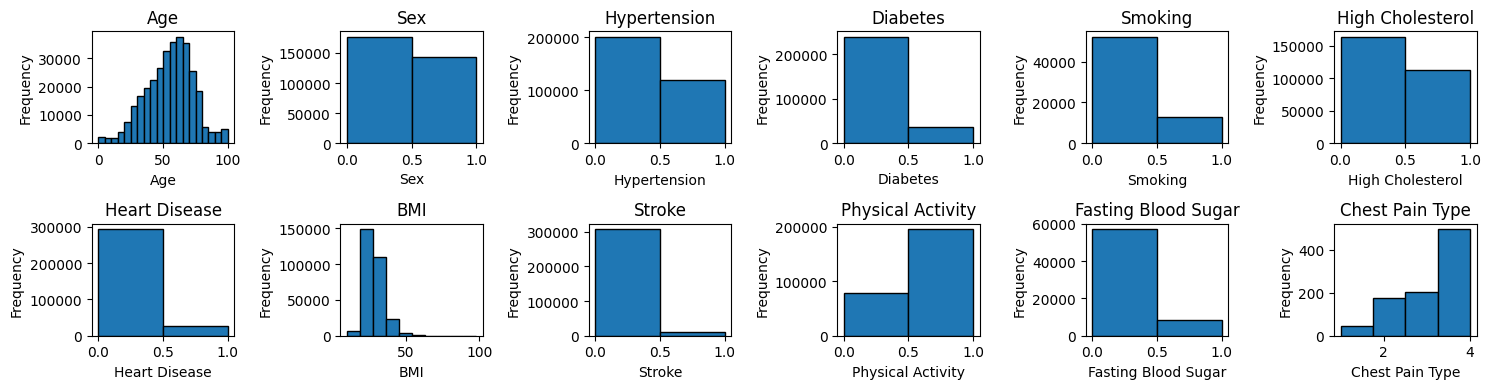

In [18]:
numerical_columns = combined_df.select_dtypes(include=['int', 'float']).columns

plt.figure(figsize=(15, 4))
for i, column in enumerate(numerical_columns, 1):
    bins = 2
    if column == "Age":
        bins = 20
    if column == "BMI":
        bins = 10
    if column == "Chest Pain Type":
        bins = 4 

    plt.subplot(2, 6, i) 
    plt.hist(combined_df[combined_df[column] != -1][column], bins=bins, edgecolor='black')
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Correlation Matrix

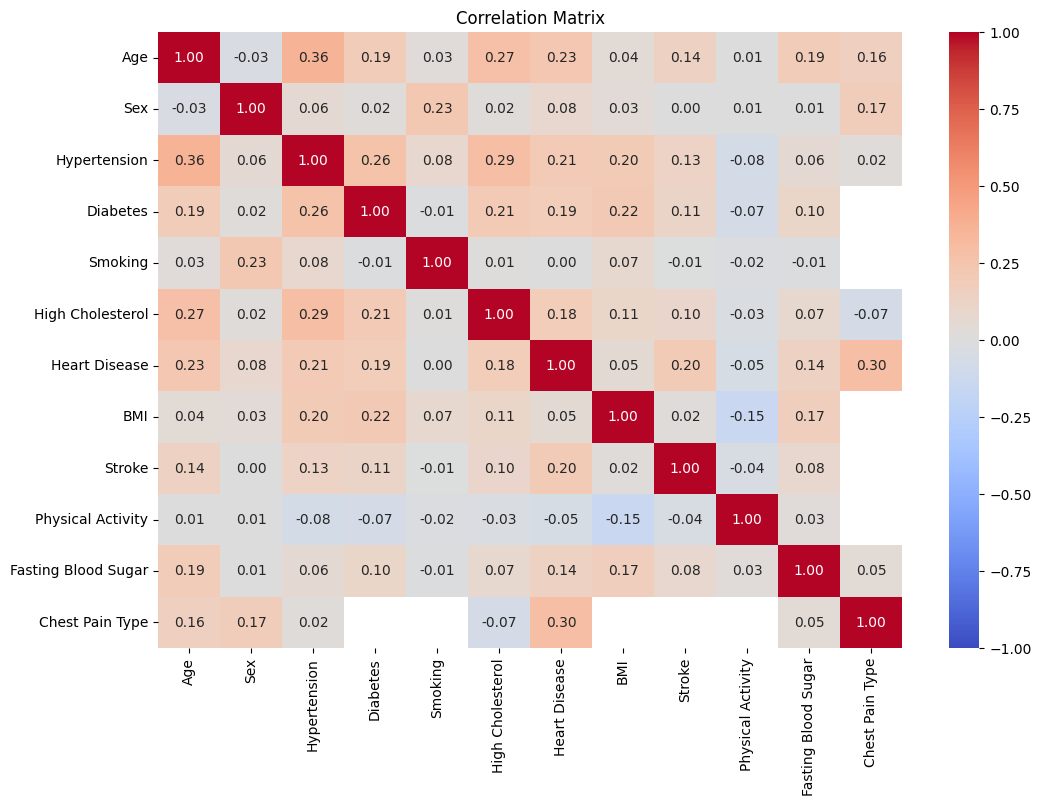

In [14]:
corr = combined_df[combined_df != -1].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


### Pair Plot of Numerical Features

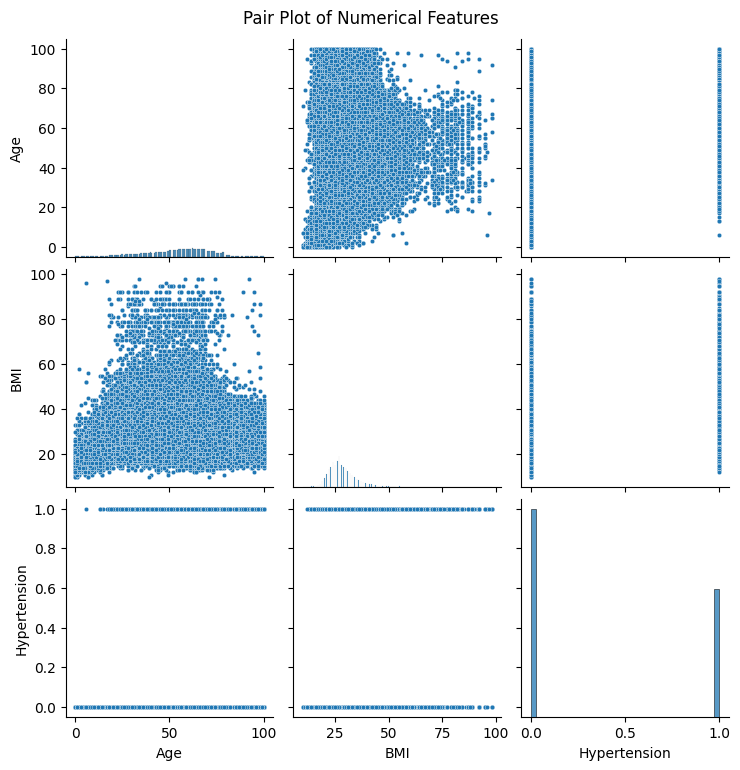

In [15]:
numerical_df = combined_df[["Age", "BMI", "Hypertension"]]
numerical_df = numerical_df[numerical_df != -1].dropna()

sns.pairplot(numerical_df, plot_kws={'s': 10})
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()


### Box Plot for Numerical Features

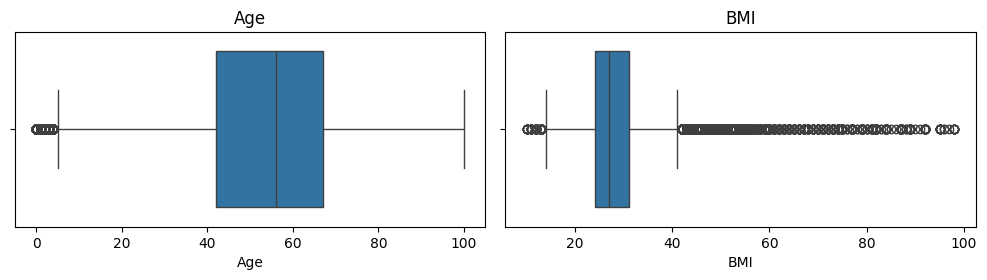

In [16]:
plt.figure(figsize=(10, 5))
for i, column in enumerate(["Age", "BMI"]):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=combined_df[column].replace(-1, pd.NA))
    plt.title(column)
    plt.xlabel(column)

plt.tight_layout()
plt.show()


In [17]:
possible_outputs = ["Hypertension", "Heart Disease", "Stroke", "Diabetes"]

for output in possible_outputs:
    rows_valid = (combined_df[output] != -1).sum()
    print(f"For {output} there are {rows_valid} rows that we can use.")

For Hypertension there are 319849 rows that we can use.
For Heart Disease there are 319609 rows that we can use.
For Stroke there are 318693 rows that we can use.
For Diabetes there are 275592 rows that we can use.
